In [ ]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
include("../scripts/TesselationCore.jl")
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end


In [2]:
using TetGen
using StaticArrays
using GLMakie
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots

import .TesselationCore


In [488]:
points3d = [TesselationCore.point3(@SVector rand(3)) for _ in 1:50]
coords, tets = TesselationCore.tesselate(points3d)
simplices = Vector([coords[:,tets[i,:]]' for i in 1:size(tets,1)])
simplex = simplices[1]


4×3 adjoint(::Matrix{Float64}) with eltype Float64:
 0.137669  0.240345  0.394081
 0.397531  0.374337  0.122168
 0.104989  0.411492  0.105593
 0.397917  0.441613  0.254667

In [ ]:
abstract type TreeNode end

struct BVHLeaf <: TreeNode
    data::Vector{Int}
end

struct BVHNode <: TreeNode
    depth::Int
    leftChild::TreeNode  #unions are apparently slow. We'll see with some benchmars
    rightChild::TreeNode
    data::Vector{Int} 
end


struct BVH
    tree::TreeNode
    bbox::Matrix{Float64}   
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix)
    indices = 1:size(boxes,3)
    return generateBVHTree(boxes,depth,limBox,indices)
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix, indices)
    
    if depth == 0 || size(boxes,3) < 2 
        if depth!=0
            println("Nontrivial leaf $depth") #REMOVE BEFORE PROD
        end
        return BVHLeaf(indices)
    end
    
    ax = depth%3 + 1

    mins = boxes[ax,1,indices]
    maxs = boxes[ax,2,indices]
    
    line = (limBox[ax,2]+limBox[ax,1])/2 

    leftIDs = indices[mins .≤ line]
    rightIDs = indices[maxs .≥ line]

    leftBox = copy(limBox)
    leftBox[ax,2] = line
    
    rightBox = copy(limBox)
    rightBox[ax,1] = line

    return BVHNode(depth,
    generateBVHTree(boxes,depth-1,leftBox,leftIDs), 
    generateBVHTree(boxes,depth-1,rightBox,rightIDs),
    indices)
end


function prepareGeneration(data) # does what BVH overload does, used for prototyping
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])

    return boxes,box

end


function BVH(data::Vector,depth::Int)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])
    tree = generateBVHTree(boxes,depth,box)
    
    return BVH(tree,box)
end

function BVH(data::Vector,depth::Int,box::Matrix)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    tree = generateBVHTree(boxes,depth,box)
    return BVH(tree,box)
end

function cornerSimplexMatr(simplex)
    return hcat(minimum(simplex,dims=1)',maximum(simplex,dims=1)') 
end

function findNeiborhood(point,bvh::BVH) #TODO
    bbox = bvh.bbox
    
end

function recursiveSearch(point,tree::BVHTree,bbox::Matrix) #TODO
    dim = tree.depth%3 + 1
    

    
end

recursiveSearch (generic function with 1 method)

In [525]:
bvh = BVH(simplices,6)
boxes, box = prepareGeneration(simplices)

([0.10498873823009125 0.39791676677286925; 0.24034539102690067 0.4416129931913969; 0.10559338287114262 0.39408112031635034;;; 0.08827706878087205 0.3424800447770049; 0.615533908598945 0.9894055638293379; 0.13121133120067807 0.4594324343622065;;; 0.06873331257473336 0.4245054521018504; 0.5343235129347376 0.7279025101722701; 0.46249816836844937 0.7671265754508199;;; … ;;; 0.6802704169234902 0.9355750490145269; 0.3109775426631821 0.7059330030475816; 0.14874809598004946 0.6503554176732333;;; 0.6802704169234902 0.9355750490145269; 0.49790192096533026 0.7059330030475816; 0.14874809598004946 0.6503554176732333;;; 0.6802704169234902 0.9355750490145269; 0.3109775426631821 0.6443601254218512; 0.14874809598004946 0.6503554176732333], [0.0019446107645350041 0.9429292767507724; 0.01356385050262432 0.9894055638293379; 0.0007085991136055458 0.9833674003077634])

In [ ]:
tree = bvh.tree
box = copy(bvh.bbox)

while typeof(tree.rightChild) == BVHTree
    depth = tree.depth
    ax = depth%3+1
    line = (box[ax,2]+box[ax,1])/2
    box[ax,1] = line
    println(box[ax,:])
    tree = tree.leftChild
end



In [537]:
println(size(simplices))
println(size(tree.data))

In [ ]:
corner = simplices[tree.data]
cboxes = boxes[:,:,tree.data]

9-element Vector{Adjoint{Float64, Matrix{Float64}}}:
 [0.1045321527163472 0.9243852446080639 0.6134630801068346; 0.0019446107645350041 0.755746281487961 0.8538663133515415; 0.17522409696560326 0.5929893612058458 0.9833674003077634; 0.8741687201825153 0.7079371452920069 0.8014183990014498]
 [0.8741687201825153 0.7079371452920069 0.8014183990014498; 0.8956380925488229 0.8971438442134432 0.6075091010977981; 0.9429292767507724 0.12771254797838338 0.2838978785241806; 0.9355750490145269 0.49790192096533026 0.14874809598004946]
 [0.8794570483111176 0.06232606882752523 0.9427373661780176; 0.8741687201825153 0.7079371452920069 0.8014183990014498; 0.8956380925488229 0.8971438442134432 0.6075091010977981; 0.9429292767507724 0.12771254797838338 0.2838978785241806]
 [0.8956380925488229 0.8971438442134432 0.6075091010977981; 0.8741687201825153 0.7079371452920069 0.8014183990014498; 0.8370430421754277 0.7059330030475816 0.6367198533943494; 0.9355750490145269 0.49790192096533026 0.14874809598004946]
 

In [ ]:
function plotBox(box,dims = [1,2])
    x,y = dims
    Plots.plot([box[x,1],box[x,1],box[x,2],box[x,2],box[x,1]],[box[y,1],box[y,2],box[y,2],box[y,1],box[y,1]],label="box")
end

function plotBox!(box,dims = [1,2])
    x,y = dims
    Plots.plot!([box[x,1],box[x,1],box[x,2],box[x,2],box[x,1]],[box[y,1],box[y,2],box[y,2],box[y,1],box[y,1]],label="box")
end

3×2×9 Array{Float64, 3}:
[:, :, 1] =
 0.00194461  0.874169
 0.592989    0.924385
 0.613463    0.983367

[:, :, 2] =
 0.874169  0.942929
 0.127713  0.897144
 0.148748  0.801418

[:, :, 3] =
 0.874169   0.942929
 0.0623261  0.897144
 0.283898   0.942737

[:, :, 4] =
 0.837043  0.935575
 0.497902  0.897144
 0.148748  0.801418

[:, :, 5] =
 0.00194461  0.895638
 0.707937    0.924385
 0.607509    0.853866

[:, :, 6] =
 0.104532  0.874169
 0.592989  0.924385
 0.613463  0.983367

[:, :, 7] =
 0.740854  0.895638
 0.621197  0.897144
 0.607509  0.801418

[:, :, 8] =
 0.104532  0.895638
 0.707937  0.924385
 0.607509  0.801418

[:, :, 9] =
 0.214561  0.895638
 0.621197  0.897144
 0.607509  0.801418

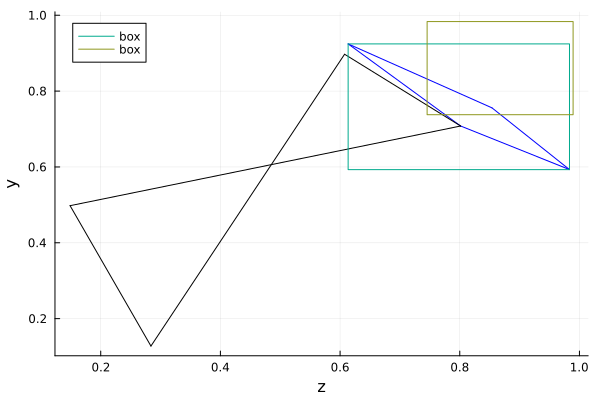

In [546]:
plot1 = Plots.plot(xlabel="x",ylabel="y")

cols = [:green,:blue,:black,:red,:orange,:purple]

for (j,simp) in enumerate(corner[[1,2]])
    J = j%6 + 1
    for i in 1:4
        if i == 4
            Plots.plot!([simp[i,1],simp[1,1]],[simp[i,2],simp[1,2]],color=cols[J],label="")
            break
        end
        Plots.plot!([simp[i,1],simp[i+1,1]],[simp[i,2],simp[i+1,2]],color=cols[J],label="")
    end
end

plotBox!(cboxes[:,:,1])

plotBox!(box)


plot2 = Plots.plot(xlabel="z",ylabel="y")

for (j,simp) in enumerate(corner[[1,2]])

    J = j%6 + 1

    for i in 1:4
        if i == 4
            Plots.plot!([simp[i,3],simp[1,3]],[simp[i,2],simp[1,2]],color=cols[J],label="")
            break
        end
        Plots.plot!([simp[i,3],simp[i+1,3]],[simp[i,2],simp[i+1,2]],color=cols[J],label="")
    end
end

plotBox!(cboxes[:,:,1],[3,2])
plotBox!(box,[2,3])


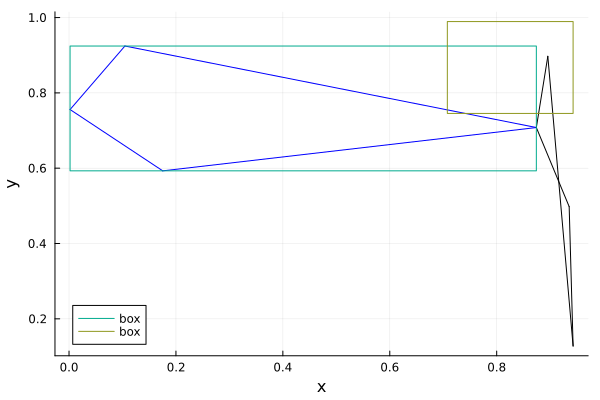

In [547]:
plot1